### Porjet XAI

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/fetal_health.csv")

X = df.drop(columns=["fetal_health"])
y = df["fetal_health"]


print(X.shape)


X.head()

(2126, 21)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0


fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64


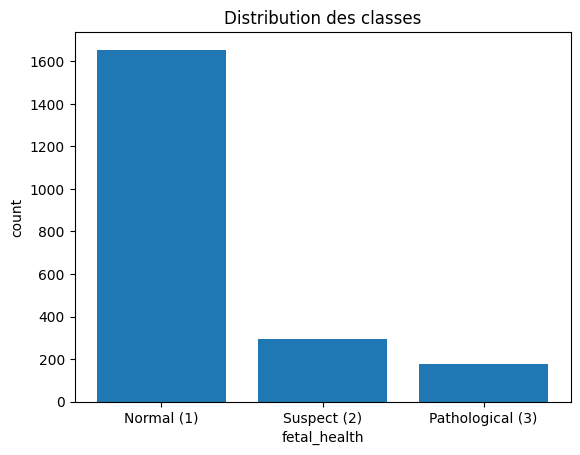

In [2]:
import matplotlib.pyplot as plt

counts = y.value_counts().sort_index()
print(counts)

plt.bar(counts.index.astype(int), counts.values)
plt.xlabel("fetal_health")
plt.ylabel("count")
plt.xticks([1, 2, 3], ["Normal (1)", "Suspect (2)", "Pathological (3)"])
plt.title("Distribution des classes")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=42, shuffle=True)

print(X_train.shape)
print(y_train.shape)

(1913, 21)
(1913,)


In [4]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)


model.fit(X_train, y_train)



ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [1. 2. 3.]